In [1]:
import pandas as pd
import numpy as np
import pybedtools
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import scipy
import math
import statsmodels
import statsmodels.stats.multitest as sm
import random
import time
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from itertools import combinations
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from scipy.stats import percentileofscore

In [2]:
tcga_path = 'data/tcga_mut_somaticgermline.tsv'
wt_path = "data/tcga_WT_drivers.tsv"
mutdelsnorm_path = "data/mut_deletion_lengths.tsv"
roles_path = "data/generoles.tsv"
bands_path = "data/genes_chromosome-bands_msigdb.tsv"
genes_path = "data/gene-coordinates_hg19.tsv"
chr_arm_coords_path = "data/chromosome-arm-coordinates.tsv"

In [3]:
tcga = pd.read_csv(tcga_path, sep = '\t')
wt = pd.read_csv(wt_path, sep = '\t')
mutdelsnorm = pd.read_csv(mutdelsnorm_path, sep='\t')
roles = pd.read_csv(roles_path, sep = '\t')
bands = pd.read_csv(bands_path, sep = '\t')
genes = pd.read_csv(genes_path, sep = '\t')
chr_arm_coords = pd.read_csv(chr_arm_coords_path, sep='\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (21,24,26) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig S6F

Preparing datasets

In [5]:
bandsmod = bands[['gene','arm']].drop_duplicates().rename(columns={'gene':'Hugo_Symbol','arm':'gene_arm'})

tcgazf_nosil = tcga[(tcga['Variant_Classification']!='Silent')&(tcga['midan_filter']=='keep')].copy()
mutdelsnorm_nosil = mutdelsnorm[mutdelsnorm['Variant_Classification']!='Silent']

zf = tcgazf_nosil[['Hugo_Symbol','tissue','Chromosome','Start_Position','End_Position','Variant_Type']].rename(columns={'Chromosome':'chrom'})
mutdelsnorm_nosil['chrom'] = mutdelsnorm_nosil['chrom'].astype('str')
zf['chrom'] = zf['chrom'].astype('str')
mutdelsnorm_zf = pd.merge(mutdelsnorm_nosil,zf,on=['Hugo_Symbol','tissue','chrom','Start_Position','End_Position','Variant_Type'])

tsgs = roles[roles['role']=='TSG']['Hugo_Symbol'].unique()
mutdelsnorm_zf_tsgs = mutdelsnorm_zf[mutdelsnorm_zf.Hugo_Symbol.isin(tsgs)][['tissue','CODE','Hugo_Symbol','chrom','del_start','del_end','del_arm','del_length_normalised','deltype','del_sa_arm','del_sa_length_normalised','deltype_sa']].drop_duplicates()

mutdelsnorm_zf_tsgs = pd.merge(mutdelsnorm_zf_tsgs,bandsmod,on='Hugo_Symbol',how='left')
mut = mutdelsnorm_zf_tsgs[['tissue','CODE','Hugo_Symbol','gene_arm','chrom','del_start','del_end','del_arm']]

/tmp/ipykernel_3700/2551634098.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutdelsnorm_nosil['chrom'] = mutdelsnorm_nosil['chrom'].astype('str')


In [6]:
# TSG 2hit epistasis unordered matrix

tsg2hits = tcgazf_nosil[(tcgazf_nosil.zygosity=='2-hit')&(tcgazf_nosil.Hugo_Symbol.isin(tsgs))]#&(tcgazf_nosil.Chromosome=='3')]
tsg2hits_epis = tsg2hits.groupby(['CODE','tissue'])['Hugo_Symbol'].value_counts().to_frame().rename(columns={'Hugo_Symbol':'count'}).reset_index()
tsg2hits_epis = tsg2hits_epis.pivot(index=['CODE','tissue'],columns='Hugo_Symbol',values='count').fillna(0)
tsg2hits_epis = tsg2hits_epis.mask(tsg2hits_epis>1,1) # capping values>1 (multiple muts in same gene) to 1

# 2hit codel unordered matrix

mut = mut[(mut['Hugo_Symbol'].isin(tsgs))]#&(mut['chrom']=='3')]
mut_codel = mut.groupby(['tissue','CODE','chrom','del_start','del_end'])['Hugo_Symbol'].value_counts().to_frame().rename(columns={'Hugo_Symbol':'count'}).reset_index()
mut_codel = mut_codel.pivot(index=['tissue','CODE','chrom','del_start','del_end'],columns='Hugo_Symbol',values='count').fillna(0)
mut_codel = mut_codel.reset_index().drop(columns=['chrom','del_start','del_end']).set_index(['CODE','tissue'])

mut_codelonly = mut_codel[mut_codel.sum(axis=1)>1].copy()
mut_codelonly = mut_codelonly.reset_index().drop_duplicates().set_index(['CODE','tissue']).copy()
tmp = mut_codelonly.reset_index()
    
df = tmp[tmp.duplicated(subset='tissue',keep=False)==True]
df.loc[:, (df != 0).any()]

Hugo_Symbol,CODE,tissue,BAP1,FAT4,NF1,PBRM1,PTPN13,SETD2,TP53,VHL
206,KIRC,TCGA-CJ-4923,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
207,KIRC,TCGA-CJ-4923,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
251,SKCM,TCGA-DA-A95X,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
252,SKCM,TCGA-DA-A95X,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [7]:
genes[genes['Gene name'].isin(['FAT4','NF1','PTPN13','TP53'])]
    # KIRC is hard to represent since there are two separate codeletions 
    # for now lets combine them into 1 row - representing 1 deletion with 4 codeletions

,Gene stable ID version,Chromosome/scaffold name,Gene start (bp),Gene end (bp),Gene name
9966,ENSG00000196159.7,4,126237554,126414087,FAT4
51161,ENSG00000196712.12,17,29421945,29709134,NF1
53097,ENSG00000163629.8,4,87515468,87736324,PTPN13
60483,ENSG00000141510.11,17,7565097,7590856,TP53


In [8]:
# doing the above

mut_codelonly = mut_codelonly.reset_index()
mut_codelonly.loc[208]['BAP1'] = 1
mut_codelonly.loc[208]['PBRM1'] = 1
mut_codelonly = mut_codelonly.drop([209])

mut_codelonly[mut_codelonly.duplicated(subset='tissue',keep=False)==True]
codel = mut_codelonly.set_index(['CODE','tissue']).copy()

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/pandas/core/series.py:1056: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cacher_needs_updating = self._check_is_chained_assignment_possible()


In [9]:
# TSG 2hit codel ordered matrix

common = np.intersect1d(tsg2hits_epis.index,mut_codel.index)
index_order = tsg2hits_epis[tsg2hits_epis.index.isin(common)].drop(columns=tsg2hits_epis.columns).reset_index()

#index_order = tsg2hits_epis.drop(columns=tsg2hits_epis.columns).reset_index()

codel_matchingorder = pd.merge(index_order,codel.reset_index(),on=['CODE','tissue'],how='left').set_index(['CODE','tissue'])
c = np.setdiff1d(tsg2hits_epis.columns.values,codel_matchingorder.columns.values)
codel_matchingorder = codel_matchingorder[tsg2hits_epis.drop(columns=c).columns]
codel_matchingorder = codel_matchingorder.fillna(0)

# changing codeleted two-hits to 2

epis_mod = tsg2hits_epis[tsg2hits_epis.index.isin(common)].copy()

epis_codel = epis_mod.add(codel_matchingorder)
len(epis_codel)

# changing codeleted two-hits to 2

common = np.intersect1d(codel_matchingorder.index,tsg2hits_epis.index)
epis_mod = tsg2hits_epis[tsg2hits_epis.index.isin(common)].copy().drop(columns=c)
codel_mod = codel_matchingorder[codel_matchingorder.index.isin(common)].copy()

epis_codel = codel_mod.add(epis_mod)
len(epis_codel)

4337

In [10]:
tumor_colors = {
    'KIRC': '#9ACD32',   # yellow-green
    'BRCA': '#DEAF05',  # golden yellow
    'OV':   '#FF6F61',  # coral
    'BLCA': '#70C9D4',  # light cyan-blue
    'HNSC': '#d55e00',  # dark orange
    'LUAD': '#E3ACC5',  # soft pink
    'SKCM': '#029E43',  # emerald green
    'STAD': '#D62981',  # magenta-pink
    'LUSC': '#0173b2',  # royal blue
    'GBM':  '#8B1C62',  # deep burgundy
    'PRAD': '#8B0000',   # dark red
    'ESCA': '#FFD700',   # vivid yellow
    'COAD': '#4B0082',   # indigo
    'TGCT': '#FF4500',   # orange-red
    'SARC': '#cbf7f3',   # turquoise
    'THCA': '#6A5ACD',   # slate blue
    'UVM':  '#8FBC8F',   # dark sea green
    'CHOL': '#A52A2A',   # brown
    'GBM':  '#2c666b',   # dark turquoise
    'OV':   '#9932CC',   # dark orchid
    'UCEC': '#F08080',   # light coral
    'PAAD': '#000000',   # black
    'KIRP': '#F0E68C',   # khaki
    'LIHC': '#B22222',   # firebrick
    'THYM': '#7FFFD4',   # aquamarine
    'MESO': '#eda1ed',   # violet
    'CESC': '#5F9EA0',   # cadet blue
    'LAML': '#D2691E',   # chocolate
    'READ': '#c29457',   # light chocolate
    'LGG':  '#f7b499',   # light salmon
    'DLBC': '#2F4F4F',   # dark slate gray
    'KICH': '#FF00FF',   # magenta
    'UCS':  '#ADFF2F',   # green-yellow
    'ACC':  '#DC143C',   # crimson
    'PCPG': '#1E90FF'    # dodger blue
}

In [11]:
# function for plotting bar above oncoplot

def plot_multicolor_bar(df, fig_width=30, fig_height=1):
    n = len(df)
    rect_height = 1.0
    rect_width = 1.0 / n  # make all rectangles fit within fixed width

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    for i, row in df.iterrows():
        rect = Rectangle((i * rect_width, 0), rect_width, rect_height,
                         facecolor=row['color'], edgecolor='none')
        ax.add_patch(rect)

    ax.set_xlim(0, 1)  
    ax.set_ylim(0, rect_height)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [12]:
# Order the samples using the oncoplot algorithm 

def oncoplot_ordering(data):
    # Define a recursive function to order the data
    def recursive_ordering(data, depth=0):
        if depth >= data.shape[1]:
            return data.index.tolist()
        
        # Order columns by column-wise sum
        primary_col = ordered_columns[depth]
        
        # Divide observations into groups based on the primary column
        group_2 = data[data[primary_col] == 2]
        group_1 = data[data[primary_col] == 1]
        group_0 = data[data[primary_col] == 0]
        
        # Recursively order within each group
        ordered_indices_2 = recursive_ordering(group_2, depth + 1)
        ordered_indices_1 = recursive_ordering(group_1, depth + 1)
        ordered_indices_0 = recursive_ordering(group_0, depth + 1)
        
        # Combine the ordered indices
        return ordered_indices_2 + ordered_indices_1 + ordered_indices_0
    
    # Start the recursive ordering
    ordered_columns = data.sum(axis=0).sort_values(ascending=False).index
    ordered_indices = recursive_ordering(data.loc[:, ordered_columns])
    return data.loc[ordered_indices, ordered_columns]

In [13]:
genes_bands = pd.merge(genes.rename(columns={'Gene name':'gene'}),bands[['gene','arm']],on='gene',how='left')
geneband = genes_bands[['gene','Chromosome/scaffold name']].copy()
geneband.columns=['gene','chr']
geneband['chr'] = geneband['chr'].astype('str')
geneband = geneband[geneband.chr.isin(['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22'])]
tsgband = geneband[geneband.gene.isin(tsgs)].drop_duplicates()

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/pandas/core/indexing.py:925: PerformanceWarning: indexing past lexsort depth may impact performance.
  return self._getitem_tuple(key)
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


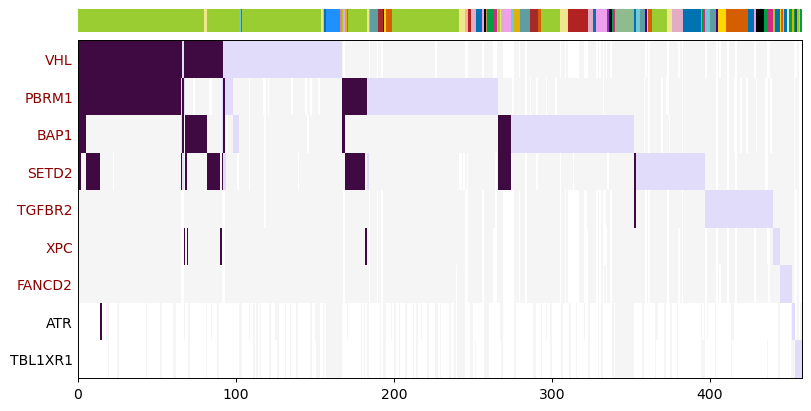

In [14]:
config_rcparams()

chr3tsgs = np.intersect1d(epis_codel.columns.values,tsgband[tsgband.chr=='3']['gene'].unique())
epis3_codel3 = epis_codel[chr3tsgs].copy()
epis3_codel3 = epis3_codel3[~(epis3_codel3 == 0).all(axis=1)]

epis3_codel3 = oncoplot_ordering(epis3_codel3)
len(epis3_codel3)

# Drop heatmap columns from tmp and assign colors
tmp = epis3_codel3.drop(columns=epis3_codel3.columns).reset_index()
tmp['color'] = tmp['CODE'].replace(tumor_colors)
tmp.set_index(['CODE','tissue'])

# Data dimensions
n_samples = tmp.shape[0]
n_genes = epis3_codel3.shape[1]
ordered_colnames = epis3_codel3.columns

# --- Create Figure and Subplots ---
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 4),         
    gridspec_kw={'height_ratios': [1, 15]}, 
    constrained_layout=True
)

# --------------------
# Plot 1: Tumor type multicolor bar
# --------------------
rect_height = 1.0
rect_width = 1.0 / n_samples

for i, row in tmp.iterrows():
    ax1.add_patch(Rectangle((i * rect_width, 0), rect_width, rect_height,
                            facecolor=row['color'], edgecolor='none'))

ax1.set_xlim(0, 1)
ax1.set_ylim(0, rect_height)
ax1.axis('off')

# --------------------
# Plot 2: Oncoplot
# --------------------

# modifying dataset to include single dels

wtdels3 = wt[(wt.Hugo_Symbol.isin(epis3_codel3.columns))&(wt.tissue.isin(epis3_codel3.reset_index().tissue.unique()))&(wt.zygosity=='1-hit')]

epis3_codel3_mod = epis3_codel3.copy()

for _, row in wtdels3.iterrows():
    gene = row['Hugo_Symbol']
    tissue = row['tissue']
    code = row['CODE']
    
    if type(epis3_codel3_mod.loc[(code, tissue), gene]) == np.float64:
        try:
            if epis3_codel3_mod.loc[(code, tissue), gene] == 0:
                epis3_codel3_mod.loc[(code, tissue), gene] = -1
        except KeyError:
            pass  
    else:
        try:
            if epis3_codel3_mod.loc[(code, tissue), gene].values[0] == 0:
                epis3_codel3_mod.loc[(code, tissue), gene].values[0] = -1
        except KeyError:
            pass

    
ax2.set_xlim(0, n_samples)
ax2.set_ylim(0, n_genes)

for i in range(epis3_codel3_mod.shape[0]):
    for j in range(epis3_codel3_mod.shape[1]):
        # draw a thin rectangle for each 1 in the data
        if epis3_codel3_mod.iloc[i, j] == 1:
            ax2.add_patch(
                plt.Rectangle(
                    (i, epis3_codel3_mod.shape[1]-1-j), 
                      1, 1, 
                      linewidth=0, color='#E0DCFA'
                )
            )
        if epis3_codel3_mod.iloc[i, j] == 2:
            ax2.add_patch(
                plt.Rectangle(
                    (i, epis3_codel3_mod.shape[1]-1-j), 
                      1, 1, 
                      linewidth=0, color='#3F0942'
                )
            )
        if epis3_codel3_mod.iloc[i, j] == -1:
            ax2.add_patch(
                plt.Rectangle(
                    (i, epis3_codel3_mod.shape[1]-1-j), 
                      1, 1, 
                      linewidth=0, color='whitesmoke'
                )
            )
            
ax2.set_yticks(np.arange(n_genes) + 0.5)
ax2.set_yticklabels(ordered_colnames[::-1], rotation=0)
#ax2.set_xticks([])  # Hide sample ticks
ax2.tick_params(axis='y', which='both', length=0)

chr3p_genes = genes_bands[genes_bands['arm']=='chr3p'].gene.unique()

for label in ax2.get_yticklabels():
    text = label.get_text()
    if any(gene in text for gene in chr3p_genes): 
        label.set_color("darkred") # p arm TSGs
    else:
        label.set_color("k") # q arm TSGs
        
plt.show()

---

# Fig 3H

Checking for significant co-occurrence

In [15]:
# preparing datasets for significance testing

bands_mod = bands[['gene','chr','arm']].copy()
bands_mod['arm'] = bands_mod['arm'].apply(lambda x:x[3:])
bands_mod['arm'] = bands_mod['arm'].astype('str')
bands_mod['chr'] = bands_mod['chr'].astype('str')
bands_mod.columns = ['Hugo_Symbol','chr','arm']
bands_mod.drop_duplicates()

tsgs = roles[roles['role']=='TSG'].Hugo_Symbol.unique()
tcga_tsg = tcga[tcga['Hugo_Symbol'].isin(tsgs)]
tcga_tsg = pd.merge(tcga_tsg,bands_mod,on='Hugo_Symbol',how='left')
tcga_tsg_nosil = tcga_tsg[(tcga_tsg['Variant_Classification']!='Silent')&(tcga_tsg['midan_filter']=='keep')]
tcga_tsg_2hit = tcga_tsg_nosil[tcga_tsg_nosil.zygosity=='2-hit']
print(len(tcga_tsg_2hit))

tsg2hits = tcga_tsg_2hit.groupby('Hugo_Symbol')['tissue'].nunique()

pair1 = []
pair2 = []
chrom = []

for g1,g2 in combinations(tsgs, 2):
    pair1.append(g1+'_'+g2)
    pair2.append(g2+'_'+g1)
    
    g1chr = bands_mod[bands_mod.Hugo_Symbol==g1]['chr'].values[0]
    g2chr = bands_mod[bands_mod.Hugo_Symbol==g2]['chr'].values[0]
    if g1chr==g2chr:
        chrom.append('same')
    else:
        chrom.append('diff')
        
tsgpairschr = pd.DataFrame({'pair1':pair1,'pair2':pair2,'chrom':chrom})

6993


In [16]:
# significance of co-occurrence

tmp = epis_codel.replace({2:1})

gene1 = []
gene2 = []
common = []

for g1,g2 in combinations(tmp.columns.values, 2):
    gene1.append(g1)
    gene2.append(g2)
    c = len(tmp[(tmp[g1]!=0)&(tmp[g2]!=0)])
    common.append(c)

cooccur = pd.DataFrame({'TSG1':gene1,'TSG2':gene2,'cooccur':common})

gene1 = []
gene2 = []
tables = []
ORs = []
pvals = []

for g1,g2 in combinations(tmp.columns.values, 2):
    
    a = cooccur[(cooccur['TSG1']==g1)&(cooccur['TSG2']==g2)]['cooccur'].values[0]
    b = tsg2hits[g2]-a
    c = tsg2hits[g1]-a
    d = 8958 - (a+b+c)
    
    table = np.array([[a, b],
                      [c, d]], dtype=int)
    
    # Haldane–Anscombe corrected OR (adds 0.5 to all cells)
    ha_or = ((a + 0.001) * (d + 0.001)) / ((b + 0.001) * (c + 0.001)) 
    # Fisher's Exact p-value
    pval = fisher_exact(table, alternative='two-sided')[1]

    
    gene1.append(g1)
    gene2.append(g2)
    tables.append(table)
    ORs.append(ha_or)
    pvals.append(pval)
    
sig = pd.DataFrame({'TSG1':gene1,'TSG2':gene2,'table':tables,'OR':ORs,'pval':pvals})
sig['pair'] = sig['TSG1']+'_'+sig['TSG2']

# FDR across all
sig['FDR'] = multipletests(sig.pval.values, method='fdr_bh')[1]

In [17]:
tmp = pd.merge(sig,tsgpairschr[['pair1','chrom']],left_on='pair',right_on='pair1',how='left')
tmp = pd.merge(tmp,tsgpairschr[['pair2','chrom']],left_on='pair',right_on='pair2',how='left')
tmp['chrom'] = tmp['chrom_x'].fillna(tmp['chrom_y'])
tmp.drop(columns=['pair1','pair2','chrom_x','chrom_y'],inplace=True)
print(len(sig)==len(tmp))
sig_mod = tmp.copy()
sig_mod = pd.merge(sig_mod,bands_mod.rename(columns={'Hugo_Symbol':'TSG1'}),on='TSG1',how='left')

# FDR for each chr
tmp = sig_mod[sig_mod.chrom=='same'].copy()
sig_mod_schr = []
for i in tmp['chr'].unique():
    subdf = tmp[tmp['chr']==i]
    subdf['FDR_chr'] = multipletests(subdf.pval.values, method='fdr_bh')[1]
    sig_mod_schr.append(subdf)
sig_mod_schr = pd.concat(sig_mod_schr)    

True


/tmp/ipykernel_3700/2097273529.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['FDR_chr'] = multipletests(subdf.pval.values, method='fdr_bh')[1]


In [18]:
# preparing dataset 

chr3tsgs = np.intersect1d(epis_codel.columns.values,tsgband[tsgband.chr=='3']['gene'].unique())
epis3_codel3 = epis_codel[chr3tsgs].copy()
epis3_codel3 = epis3_codel3[~(epis3_codel3 == 0).all(axis=1)]

# 2-hit co-occurrence

tmp = epis3_codel3.replace({2:1})
epis3 = tmp.T.dot(tmp)

order3 = genes_bands[genes_bands['gene'].isin(epis3.columns.values)].sort_values(by=['Gene start (bp)'])['gene'].unique()
epis3 = epis3[order3].loc[order3]

totmut3 = pd.DataFrame(columns=epis3.columns.values)
for gene1 in epis3.columns.values:
    totmut3.loc[0,gene1] = (tmp[gene1] == 1).sum()
totmut3 = totmut3.astype(int)

episprop3 = epis3.copy()

for gene1 in epis3.columns.values:
    episprop3[gene1] = episprop3[gene1]/totmut3.loc[0,gene1]
    
# prop of 2-cooccurrence that are due to codel

tmp = epis3_codel3.replace({1:0,2:1})
codel3 = tmp.T.dot(tmp)
codel3 = codel3[order3].loc[order3]

codelbyepis3 = codel3/epis3
np.fill_diagonal(codelbyepis3.values, np.nan)


sig3 = sig_mod[sig_mod.chr=='3']

tmp = pd.merge(sig3,tsgpairschr[['pair1','chrom']],left_on='pair',right_on='pair1',how='left')
tmp = pd.merge(tmp,tsgpairschr[['pair2','chrom']],left_on='pair',right_on='pair2',how='left')
tmp['chrom'] = tmp['chrom_x'].fillna(tmp['chrom_y'])
tmp.drop(columns=['pair1','pair2','chrom_x','chrom_y'],inplace=True)
print(len(sig3)==len(tmp))
sig3 = tmp.copy()
sig3 = pd.merge(sig3,bands_mod.rename(columns={'Hugo_Symbol':'TSG1'}),on='TSG1',how='left')

# Significance annotation

sigannot3 = pd.DataFrame(index=epis3.index, columns=epis3.columns)
fdr3 = sig3[sig3.FDR<=0.05]

for gene1,gene2 in zip(fdr3['TSG1'].values,fdr3['TSG2'].values):
    sigannot3.loc[gene1,gene2] = '*'#s
    sigannot3.loc[gene2,gene1] = '*'#s
    
sig3mod = sig3[['TSG1','TSG2','OR','FDR']]

# Pivot to form matrices for OR and FDR
or_matrix3 = sig3mod.pivot(index="TSG1", columns="TSG2", values="OR")
fdr_matrix3 = sig3mod.pivot(index="TSG1", columns="TSG2", values="FDR")

# Ensure both axes contain all 9 genes in the same order
genes = sorted(set(sig3mod["TSG1"]) | set(sig3mod["TSG2"]))
or_matrix3 = or_matrix3.reindex(index=genes, columns=genes)
fdr_matrix3 = fdr_matrix3.reindex(index=genes, columns=genes)

or_matrix3 = or_matrix3[order3].loc[order3]
fdr_matrix3 = fdr_matrix3[order3].loc[order3]

# Create annotation matrix with '*' for FDR < 0.05
annot_matrix3 = fdr_matrix3.applymap(lambda x: "*" if pd.notnull(x) and x < 0.05 else "")

# making the matrices symmetric
or_matrix3 = or_matrix3.combine_first(or_matrix3.T)
fdr_matrix3 = fdr_matrix3.combine_first(fdr_matrix3.T)

# Annotation matrix: '*' where FDR < 0.05
fdrannot_matrix3 = fdr_matrix3.applymap(lambda x: "*" if pd.notnull(x) and x < 0.05 else "")

# Mask upper triangle so each pair is shown once
mask_upper3 = np.tril(np.ones_like(or_matrix3, dtype=bool), k=-1)
mask_lower3 = np.triu(np.ones_like(or_matrix3, dtype=bool), k=1)

True


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


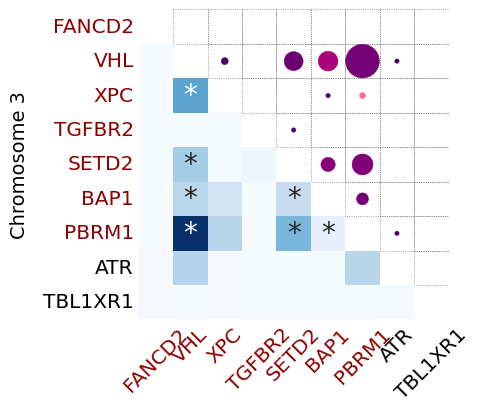

In [19]:
config_rcparams()

fig, ax = plt.subplots(figsize=(4, 5.7))

# Heatmap
sns.heatmap(
    or_matrix3,
    cmap="Blues",
    annot=fdrannot_matrix3,
    fmt="",
    cbar=False,
    mask=mask_lower3,
    vmin=-0.5, vmax=60,
    ax=ax,
    annot_kws={"fontsize": 20}
)

n = codelbyepis3.shape[0]
x, y = np.meshgrid(np.arange(n), np.arange(n))

# Mask upper triangle 
mask = np.triu(np.ones_like(codelbyepis3, dtype=bool), k=1)

xvals = x[mask].flatten()
yvals = y[mask].flatten()
colors = codelbyepis3.values[mask].flatten()
sizes = epis3.values[mask].flatten()

# Normalize bubble sizes
sizes_scaled = (sizes - 1) / (100 - 1) * 800 + 10

for i, j in zip(xvals, yvals):
    ax.add_patch(Rectangle((i, j), 1, 1, fill=False,
                           edgecolor='grey', linestyle=':', lw=0.6, zorder=1))


sc = ax.scatter(
    xvals + 0.5, yvals + 0.5,
    s=sizes_scaled,
    c=colors,
    cmap="RdPu",
    vmin=0, vmax=1,
    edgecolor=None, linewidth=0.3,
    zorder=3, clip_on=False
)

# Keep square aspect
ax.set_aspect("equal")

# labels

chr3p_genes = genes_bands[genes_bands['arm']=='chr3p'].gene.unique()

for label in ax.get_xticklabels():
    text = label.get_text()
    if any(gene in text for gene in chr3p_genes):
        label.set_color("darkred") # p arm TSGs
    else:
        label.set_color("k") # q arm TSGs
        
for label in ax.get_yticklabels():
    text = label.get_text()
    if any(gene in text for gene in chr3p_genes):  
        label.set_color("darkred") # p arm TSGs
    else:
        label.set_color("k") # q arm TSGs

ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', which='both', length=0)
        
plt.ylabel('Chromosome 3',labelpad=10, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45, fontsize=14.5)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0, fontsize=14.5)
plt.xlabel(None)

plt.show()

----

# Fig S6G

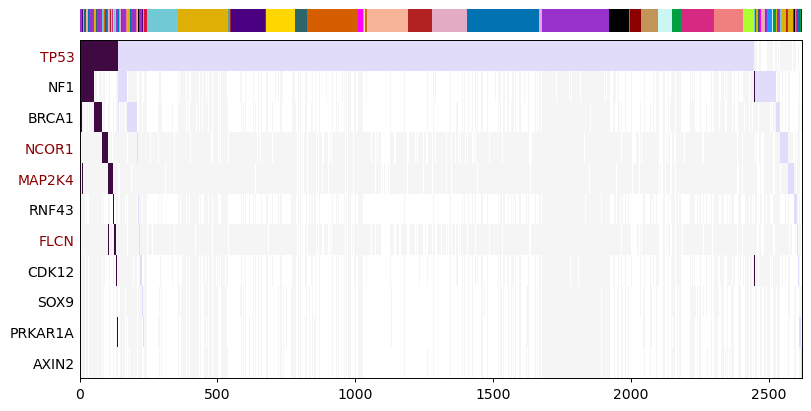

In [20]:
config_rcparams()

chr17tsgs = np.intersect1d(epis_codel.columns.values,tsgband[tsgband.chr=='17']['gene'].unique())
epis17_codel17 = epis_codel[chr17tsgs].copy()
epis17_codel17 = epis17_codel17[~(epis17_codel17 == 0).all(axis=1)]

epis17_codel17 = oncoplot_ordering(epis17_codel17)
len(epis17_codel17)

# Drop heatmap columns from tmp and assign colors
tmp = epis17_codel17.drop(columns=epis17_codel17.columns).reset_index()
tmp['color'] = tmp['CODE'].replace(tumor_colors)
tmp.set_index(['CODE','tissue'])

n_samples = tmp.shape[0]
n_genes = epis17_codel17.shape[1]
ordered_colnames = epis17_codel17.columns

fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(8, 4),         
    gridspec_kw={'height_ratios': [1, 15]},  
    constrained_layout=True
)

# --------------------
# Plot 1: Tumor type multicolor bar
# --------------------
rect_height = 1.0
rect_width = 1.0 / n_samples

for i, row in tmp.iterrows():
    ax1.add_patch(Rectangle((i * rect_width, 0), rect_width, rect_height,
                            facecolor=row['color'], edgecolor='none'))

ax1.set_xlim(0, 1)
ax1.set_ylim(0, rect_height)
ax1.axis('off')

# --------------------
# Plot 2: Oncoplot
# --------------------

# modifying dataset to include single dels

wtdels17 = wt[(wt.Hugo_Symbol.isin(epis17_codel17.columns))&(wt.tissue.isin(epis17_codel17.reset_index().tissue.unique()))&(wt.zygosity=='1-hit')]

epis17_codel17_mod = epis17_codel17.copy()

for _, row in wtdels17.iterrows():
    gene = row['Hugo_Symbol']
    tissue = row['tissue']
    code = row['CODE']
    
    if type(epis17_codel17_mod.loc[(code, tissue), gene]) == np.float64:
        try:
            if epis17_codel17_mod.loc[(code, tissue), gene] == 0:
                epis17_codel17_mod.loc[(code, tissue), gene] = -1
        except KeyError:
            pass  
    else:
        try:
            if epis17_codel17_mod.loc[(code, tissue), gene].values[0] == 0:
                epis17_codel17_mod.loc[(code, tissue), gene].values[0] = -1
        except KeyError:
            pass 

    
ax2.set_xlim(0, n_samples)
ax2.set_ylim(0, n_genes)

for i in range(epis17_codel17_mod.shape[0]):
    for j in range(epis17_codel17_mod.shape[1]):
        # draw a thin rectangle for each 1 in the data
        if epis17_codel17_mod.iloc[i, j] == 1:
            ax2.add_patch(
                plt.Rectangle(
                    (i, epis17_codel17_mod.shape[1]-1-j), 
                      1, 1, 
                      linewidth=0, color='#E0DCFA'
                )
            )
        if epis17_codel17_mod.iloc[i, j] == 2:
            ax2.add_patch(
                plt.Rectangle(
                    (i, epis17_codel17_mod.shape[1]-1-j), 
                      1, 1, 
                      linewidth=0, color='#3F0942'
                )
            )
        if epis17_codel17_mod.iloc[i, j] == -1:
            ax2.add_patch(
                plt.Rectangle(
                    (i, epis17_codel17_mod.shape[1]-1-j), 
                      1, 1, 
                      linewidth=0, color='whitesmoke'
                )
            )
            
ax2.set_yticks(np.arange(n_genes) + 0.5)
ax2.set_yticklabels(ordered_colnames[::-1], rotation=0)
ax2.tick_params(axis='y', which='both', length=0)

chr17p_genes = genes_bands[genes_bands['arm']=='chr17p'].gene.unique()

for label in ax2.get_yticklabels():
    text = label.get_text()
    if any(gene in text for gene in chr17p_genes):  
        label.set_color("darkred") # p arm TSGs
    else:
        label.set_color("k") # q arm TSGs

plt.show()

---

# Fig 3I

In [21]:
# Preparing dataset

chr17tsgs = np.intersect1d(epis_codel.columns.values,tsgband[tsgband.chr=='17']['gene'].unique())
epis17_codel17 = epis_codel[chr17tsgs].copy()
epis17_codel17 = epis17_codel17[~(epis17_codel17 == 0).all(axis=1)]

# 2-hit co-occurrence

tmp = epis17_codel17.replace({2:1})
epis17 = tmp.T.dot(tmp)

order17 = genes_bands[genes_bands['gene'].isin(epis17.columns.values)].sort_values(by=['Gene start (bp)'])['gene'].unique()
epis17 = epis17[order17].loc[order17]

totmut17 = pd.DataFrame(columns=epis17.columns.values)
for gene1 in epis17.columns.values:
    totmut17.loc[0,gene1] = (tmp[gene1] == 1).sum()
totmut17 = totmut17.astype(int)

episprop17 = epis17.copy()

for gene1 in epis17.columns.values:
    episprop17[gene1] = episprop17[gene1]/totmut17.loc[0,gene1]
    
# prop of 2-cooccurrence that are due to codel
tmp = epis17_codel17.replace({1:0,2:1})
codel17 = tmp.T.dot(tmp)
codel17 = codel17[order17].loc[order17]

codelbyepis17 = codel17/epis17
np.fill_diagonal(codelbyepis17.values, np.nan)

sig17 = sig_mod[sig_mod.chr=='17']

tmp = pd.merge(sig17,tsgpairschr[['pair1','chrom']],left_on='pair',right_on='pair1',how='left')
tmp = pd.merge(tmp,tsgpairschr[['pair2','chrom']],left_on='pair',right_on='pair2',how='left')
tmp['chrom'] = tmp['chrom_x'].fillna(tmp['chrom_y'])
tmp.drop(columns=['pair1','pair2','chrom_x','chrom_y'],inplace=True)
print(len(sig17)==len(tmp))
sig17 = tmp.copy()
sig17 = pd.merge(sig17,bands_mod.rename(columns={'Hugo_Symbol':'TSG1'}),on='TSG1',how='left')

# Significance annotation

sigannot17 = pd.DataFrame(index=epis17.index, columns=epis17.columns)
fdr17 = sig17[sig17.FDR<=0.05]

for gene1,gene2 in zip(fdr17['TSG1'].values,fdr17['TSG2'].values):
    sigannot17.loc[gene1,gene2] = '*'
    sigannot17.loc[gene2,gene1] = '*'
    
sig17mod = sig17[['TSG1','TSG2','OR','FDR']]

# Pivot to form matrices for OR and FDR
or_matrix17 = sig17mod.pivot(index="TSG1", columns="TSG2", values="OR")
fdr_matrix17 = sig17mod.pivot(index="TSG1", columns="TSG2", values="FDR")

# Ensure both axes contain all 9 genes in the same order
genes = sorted(set(sig17mod["TSG1"]) | set(sig17mod["TSG2"]))
or_matrix17 = or_matrix17.reindex(index=genes, columns=genes)
fdr_matrix17 = fdr_matrix17.reindex(index=genes, columns=genes)

or_matrix17 = or_matrix17[order17].loc[order17]
fdr_matrix17 = fdr_matrix17[order17].loc[order17]

# Create annotation matrix with '*' for FDR < 0.05
annot_matrix17 = fdr_matrix17.applymap(lambda x: "*" if pd.notnull(x) and x < 0.05 else "")

# making the matrices symmetric
or_matrix17 = or_matrix17.combine_first(or_matrix17.T)
fdr_matrix17 = fdr_matrix17.combine_first(fdr_matrix17.T)

# Annotation matrix: '*' where FDR < 0.05
fdrannot_matrix17 = fdr_matrix17.applymap(lambda x: "*" if pd.notnull(x) and x < 0.05 else "")

# Mask upper triangle so each pair is shown once
mask_upper17 = np.tril(np.ones_like(or_matrix17, dtype=bool), k=-1)
mask_lower17 = np.triu(np.ones_like(or_matrix17, dtype=bool), k=1)

True


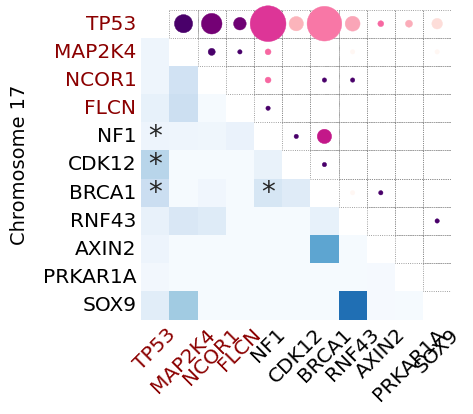

In [22]:
config_rcparams()

fig, ax = plt.subplots(figsize=(4, 5.7))

# Heatmap 
sns.heatmap(
    or_matrix17,
    cmap="Blues",
    annot=fdrannot_matrix17,
    fmt="",
    cbar=False,
    mask=mask_lower17,
    vmin=-0.5, vmax=60,
    ax=ax,
    annot_kws={"fontsize": 20}
)

# Bubble overlay for upper triangle 
n = codelbyepis17.shape[0]
x, y = np.meshgrid(np.arange(n), np.arange(n))

# Mask upper triangle (exclude diagonal)
mask = np.triu(np.ones_like(codelbyepis17, dtype=bool), k=1)

xvals = x[mask].flatten()
yvals = y[mask].flatten()
colors = codelbyepis17.values[mask].flatten()
sizes = epis17.values[mask].flatten()

# Normalize bubble sizes
sizes_scaled = (sizes - 1) / (100 - 1) * 800 + 10

for i, j in zip(xvals, yvals):
    ax.add_patch(Rectangle((i, j), 1, 1, fill=False,
                           edgecolor='grey', linestyle=':', lw=0.6, zorder=1))

sc = ax.scatter(
    xvals + 0.5, yvals + 0.5,
    s=sizes_scaled,
    c=colors,
    cmap="RdPu",
    vmin=0, vmax=1,
    edgecolor=None, linewidth=0.3,
    zorder=3, clip_on=False
)

ax.set_aspect("equal")

chr17p_genes = genes_bands[genes_bands['arm']=='chr17p'].gene.unique()

for label in ax.get_xticklabels():
    text = label.get_text()
    if any(gene in text for gene in chr17p_genes): 
        label.set_color("darkred") # p arm TSGs
    else:
        label.set_color("k") # q arm TSGs
        
for label in ax.get_yticklabels():
    text = label.get_text()
    if any(gene in text for gene in chr17p_genes): 
        label.set_color("darkred") # p arm TSGs
    else:
        label.set_color("k") # q arm TSGs

ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', which='both', length=0)
        
plt.ylabel('Chromosome 17',labelpad=10, fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45, fontsize=14.5)
ax.set_yticklabels(ax.get_yticklabels(),rotation=0, fontsize=14.5)
plt.xlabel(None)

plt.show()

---